<a href="https://colab.research.google.com/github/LaraDondossola/Data-science/blob/main/Aula_series_temporais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Aula prática - Séries Temporais
# Modelos: SES, Holt Linear e Holt-Winters


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import Holt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error


# -------------------------------
# 1. Criando uma série temporal
# -------------------------------

np.random.seed(42)

# Criando datas mensais de janeiro/2020 até dezembro/2024
datas = pd.date_range(start="2020-01-01", end="2024-12-01", freq="MS")

# Quantidade de períodos
n = len(datas)

# Tendência: crescimento gradual ao longo do tempo
tendencia = np.linspace(100, 180, n)

# Sazonalidade: padrão que se repete a cada 12 meses
sazonalidade = 20 * np.sin(2 * np.pi * np.arange(n) / 12)

# Ruído: variação aleatória
ruido = np.random.normal(0, 5, n)

# Série final
vendas = tendencia + sazonalidade + ruido

# Criando DataFrame
df = pd.DataFrame({
    "data": datas,
    "vendas": vendas
})

df.set_index("data", inplace=True)

# Visualizando os primeiros dados
print(df.head())

                vendas
data                  
2020-01-01  102.483571
2020-02-01  110.664611
2020-03-01  123.270815
2020-04-01  131.682946
2020-05-01  121.573470


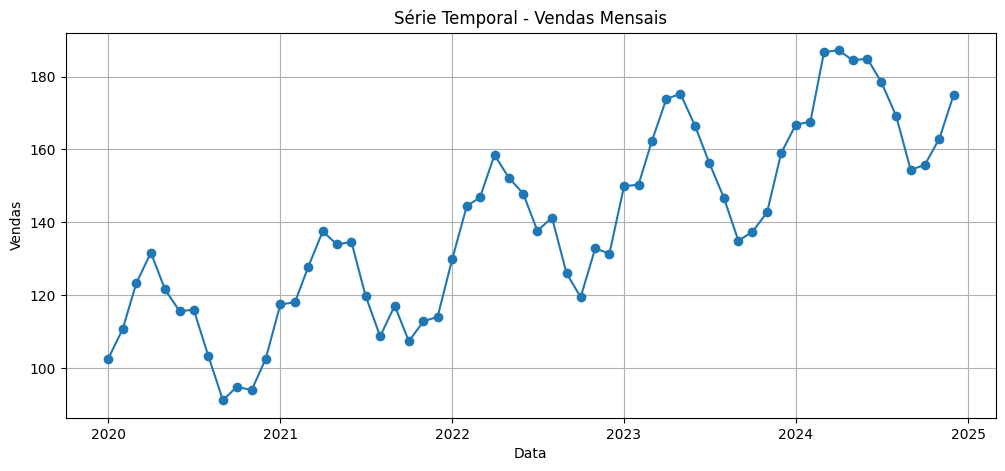

In [2]:
### Visualizando a série de dados
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["vendas"], marker="o")
plt.title("Série Temporal - Vendas Mensais")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.grid(True)
plt.show()

In [3]:
# Separando em treino e teste
treino = df.loc[:"2023-12-01", "vendas"]
teste = df.loc["2024-01-01":, "vendas"]

print("Tamanho treino:", len(treino))
print("Tamanho teste:", len(teste))

Tamanho treino: 48
Tamanho teste: 12


In [4]:
## O SES tenta prever o futuro com base em uma média suavizada dos valores anteriores.
## Ele funciona melhor quando a série está relativamente estável, sem crescimento claro e sem ciclos sazonais.

modelo_ses = SimpleExpSmoothing(treino).fit()

previsao_ses = modelo_ses.forecast(len(teste))

print(previsao_ses)

2024-01-01    159.014424
2024-02-01    159.014424
2024-03-01    159.014424
2024-04-01    159.014424
2024-05-01    159.014424
2024-06-01    159.014424
2024-07-01    159.014424
2024-08-01    159.014424
2024-09-01    159.014424
2024-10-01    159.014424
2024-11-01    159.014424
2024-12-01    159.014424
Freq: MS, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [5]:
## O modelo Holt já entende que a série está crescendo.
## Por isso, sua previsão tende a subir ao longo do tempo. Porém, ele ainda não entende que existem meses naturalmente mais altos ou mais baixos.
modelo_holt = Holt(treino).fit()
previsao_holt = modelo_holt.forecast(len(teste))

print(previsao_holt)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


2024-01-01    170.167278
2024-02-01    183.784828
2024-03-01    197.402377
2024-04-01    211.019927
2024-05-01    224.637477
2024-06-01    238.255026
2024-07-01    251.872576
2024-08-01    265.490126
2024-09-01    279.107675
2024-10-01    292.725225
2024-11-01    306.342775
2024-12-01    319.960324
Freq: MS, dtype: float64


In [6]:
## O modelo Holt

#Como a série é mensal e o padrão se repete a cada ano, usamos:
seasonal_periods=12
modelo_hw = ExponentialSmoothing(
    treino,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

previsao_hw = modelo_hw.forecast(len(teste))

print(previsao_hw)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


2024-01-01    163.729374
2024-02-01    169.705545
2024-03-01    178.811467
2024-04-01    189.208983
2024-05-01    184.582538
2024-06-01    179.954271
2024-07-01    171.302820
2024-08-01    163.849530
2024-09-01    156.132462
2024-10-01    153.602749
2024-11-01    159.421618
2024-12-01    165.572939
Freq: MS, dtype: float64


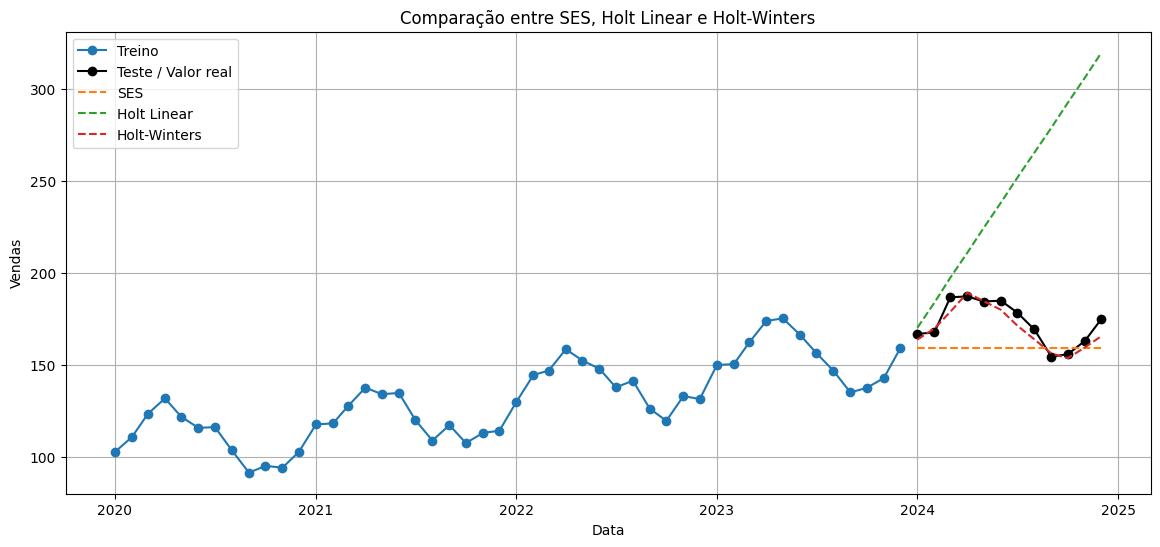

In [7]:
plt.figure(figsize=(14, 6))

plt.plot(treino.index, treino, label="Treino", marker="o")
plt.plot(teste.index, teste, label="Teste / Valor real", marker="o", color="black")

plt.plot(previsao_ses.index, previsao_ses, label="SES", linestyle="--")
plt.plot(previsao_holt.index, previsao_holt, label="Holt Linear", linestyle="--")
plt.plot(previsao_hw.index, previsao_hw, label="Holt-Winters", linestyle="--")

plt.title("Comparação entre SES, Holt Linear e Holt-Winters")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
def calcular_metricas(y_real, y_previsto):
    mae = mean_absolute_error(y_real, y_previsto)
    rmse = np.sqrt(mean_squared_error(y_real, y_previsto))
    return mae, rmse


mae_ses, rmse_ses = calcular_metricas(teste, previsao_ses)
mae_holt, rmse_holt = calcular_metricas(teste, previsao_holt)
mae_hw, rmse_hw = calcular_metricas(teste, previsao_hw)


resultados = pd.DataFrame({
    "Modelo": ["SES", "Holt Linear", "Holt-Winters"],
    "MAE": [mae_ses, mae_holt, mae_hw],
    "RMSE": [rmse_ses, rmse_holt, rmse_hw]
})

print(resultados)

         Modelo        MAE       RMSE
0           SES  15.079390  17.785170
1   Holt Linear  72.281848  89.439836
2  Holt-Winters   4.111918   4.924359
